In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay

In [4]:
data=pd.read_csv('Social_Network_Ads.csv')
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
data['Gender_encoded']=data['Gender'].map({'Male':1,'Female':0})

In [7]:
x=data[['Age','EstimatedSalary','Gender_encoded']]
y=data['Purchased']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [10]:
base_estimators=[
    ('lr',LogisticRegression()),
    ('dt',DecisionTreeClassifier()),
    ('knn',KNeighborsClassifier())
]
stacking_clf=StackingClassifier(estimators=base_estimators,final_estimator=LogisticRegression(),cv=5)
stacking_clf.fit(x_train,y_train)


,estimators,"[('lr', ...), ('dt', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


Stacking Classifier Accuracy: 0.9


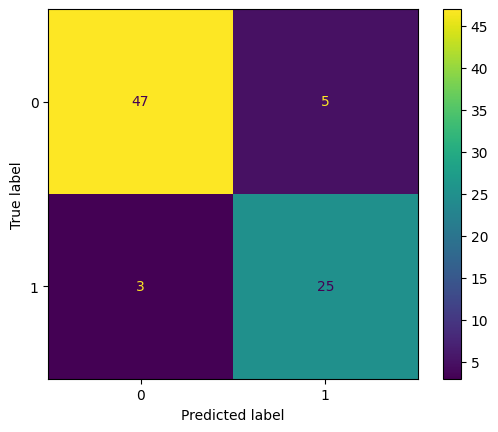

In [11]:
y_pred=stacking_clf.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Stacking Classifier Accuracy:",accuracy)
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()